# Triton $^3H$ Ground State computation

In [1]:
# we set some needed constants
hbarc = 197.327 # [MeV fm]
MN0 = (938.27231 + 939.56563) / 2 # average nucleon mass [MeV]
MN = MN0 / hbarc**2 # average nucleon mass in units [MeV^-1 fm^-2]

Kinetic energy - shape: (632, 632), max: 230.0, min: -43.7410103
Potential - shape: (632, 632), max: 16.7176796, min: -21.5521279


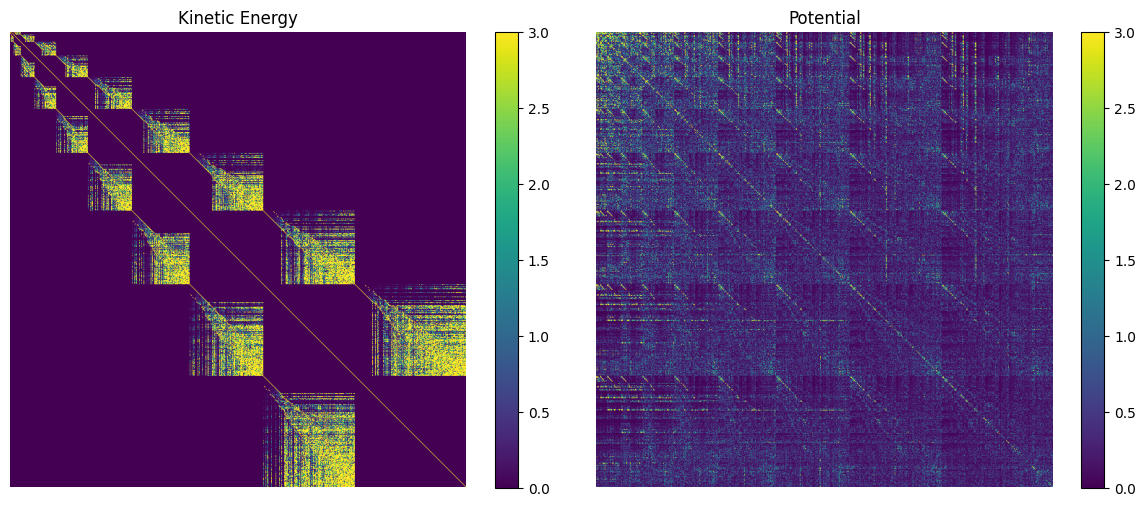

In [2]:
# we import the matrix elements from the data files and display them
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
from visualization import plot_matrix

TMat_path = './data/kinetic_EMax20_hw20.dat'
VMat_path = './data/chi2b3b_EMax20_hw20.dat'

TMat = np.loadtxt(TMat_path)
VMat = np.loadtxt(VMat_path)
print(f"Kinetic energy - shape: {TMat.shape}, max: {TMat.max()}, min: {TMat.min()}")
print(f"Potential - shape: {VMat.shape}, max: {VMat.max()}, min: {VMat.min()}")

fig = plot_matrix(
    [TMat, VMat], 
    titles=["Kinetic Energy", "Potential"],
    shape=(1, 2),
    clip=(0, 3),
    figsize=(12, 5)
)
plt.show()
fig.savefig('./figs/init_matrix.png')

In [4]:
# we run a integrator of the flow equations
from euler_integrator import EulerIntegrator

# define the flow equation derivative
def flow_var(Hn, t):
    prod = (TMat @ Hn @ Hn) - (2 * Hn @ TMat @ Hn) + Hn @ Hn @ TMat
    return (MN**2) * prod

integrator = EulerIntegrator(flow_var, 0.0001)
points, times = integrator.evolve(TMat + VMat, 50000, checkpoints=20, verbose=True, init_msg="Evolving SRG flow")

checkpoints:
[    1  2632  5264  7895 10527 13158 15790 18421 21053 23684 26316 28947
 31579 34210 36842 39473 42105 44736 47368 50000]
Evolving SRG flow


100%|█████████████████| 50000/50000 [49:05<00:00, 16.98it/s]


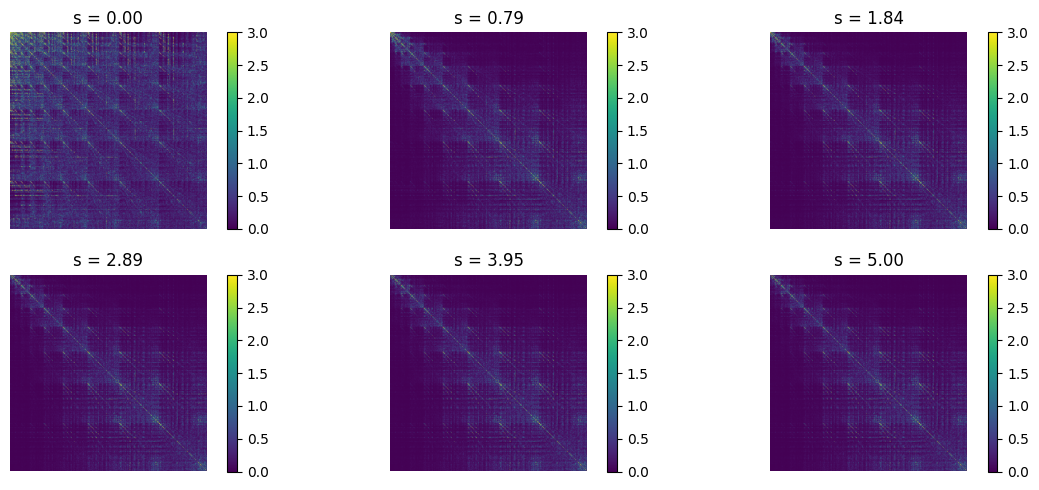

In [5]:
# plot some of the flow matrices (isolating the interaction)
%matplotlib inline

import matplotlib.pyplot as plt
from visualization import plot_matrix

plt_ind = [0, 4, 8, 12, 16, 20]
plt_mat = points[plt_ind]
plt_t = times[plt_ind]

fig = plot_matrix(
    matrices=[(mat - TMat) for mat in plt_mat], 
    titles=[f"s = {s:.2f}" for s in plt_t],
    shape=(2, 3),
    clip=(0, 3),
    figsize=(12, 5)
)

plt.show()
fig.savefig('./figs/flow_matrix.png')

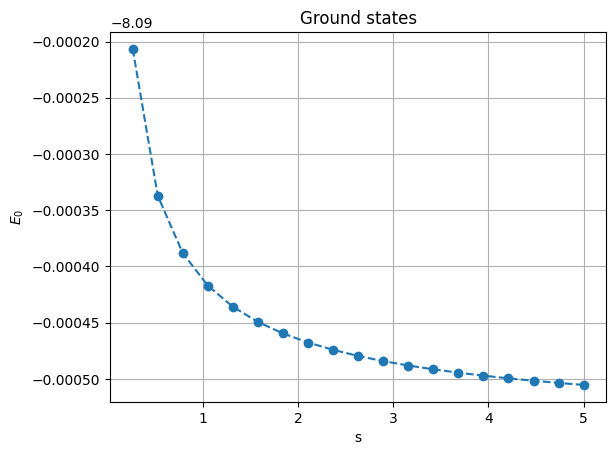

s = 5.000000000001686
ground state = -8.090505437641466


In [6]:
# Finally we find the lowest energy eigenvalue by diagonalizing the resulting matrix
import matplotlib.pyplot as plt

ground_states = []
for mat in points[2:]:
    eigenvalues, _ = np.linalg.eigh(mat)
    ground_states.append(eigenvalues[0])

plt.plot(times[2:], ground_states, linestyle='--', marker='o')
plt.title("Ground states")
plt.xlabel("s")
plt.ylabel("$E_0$")
plt.grid(True)
plt.savefig('figs/ground_states.png')
plt.show()

print(f"s = {times[-1]}")
print(f"ground state = {ground_states[-1]}")

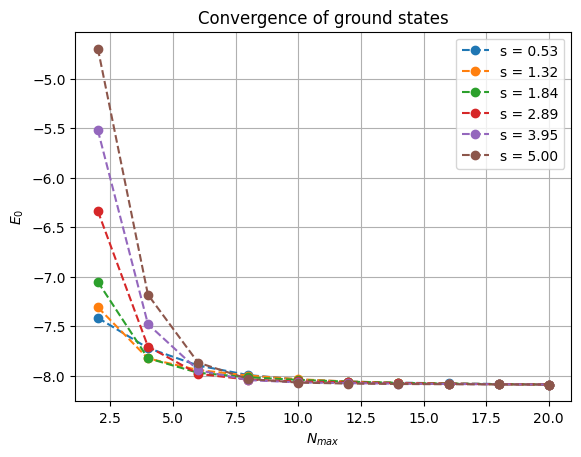

In [21]:
# We can check convergence for different values of N_max
import numpy as np

n_maxs = [2, 4, 6, 8, 10, 12, 14, 16, 18, 20];
dims = [5, 15, 34, 64, 108, 169, 249, 351, 478, 632];

plt_ind = [3, 6, 8, 12, 16, 20]
plt_mat = points[plt_ind]
plt_t = times[plt_ind]

conv_list = []
for mat in plt_mat:
    dim_list = []
    for dim in dims:
        H_sub = mat[:dim, :dim]
        eigenvalues, _ = np.linalg.eigh(H_sub)
        dim_list.append(eigenvalues[0])
    conv_list.append(dim_list)


# plot convergence of g.s. for different flow params
for i, time in zip(conv_list, plt_t):
    plt.plot(n_maxs, i, linestyle='--', marker='o', label=f"s = {time:.2f}")

plt.title("Convergence of ground states")
plt.xlabel(r"$N_{max}$")
plt.ylabel(r"$E_0$")
plt.grid(True)
plt.legend()
plt.savefig('figs/conv_lists.png')
plt.show()